In [1]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms, models
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [4]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

In [5]:
batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
print(f'MNIST: train {train_dataset.data.shape}, test {test_dataset.data.shape}')

MNIST: train torch.Size([60000, 28, 28]), test torch.Size([10000, 28, 28])


In [7]:
print(f'MNIST: {train_dataset.classes}')

MNIST: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


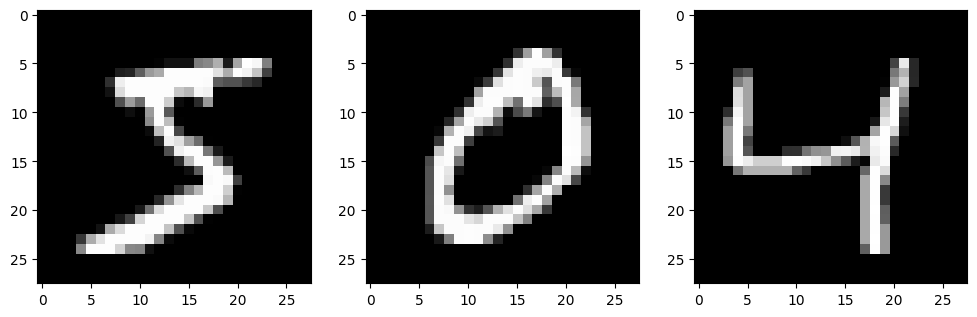

In [8]:
#show images
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(train_dataset.data[0], cmap='gray')
ax[1].imshow(train_dataset.data[1], cmap='gray')
ax[2].imshow(train_dataset.data[2], cmap='gray')
plt.show()


In [9]:
model = models.densenet121(weights="DEFAULT")

In [10]:
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [11]:
# modify the input and output layers
model.features.conv0 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.classifier = nn.Linear(1024, 10)
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [12]:
lr = 0.0001

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
best_val_loss = float('inf')
epochs = 10

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    tarin_bar = tqdm(train_loader, position=0, leave=True)
    for x, y in tarin_bar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        class_pred = y_pred.argmax(dim=1)
        train_correct += class_pred.eq(y).sum().item()
    train_accuracy = train_correct / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_bar = tqdm(test_loader, position=0, leave=True)
    with torch.no_grad():
        for x, y in val_bar:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_loss += loss.item()
            class_pred = y_pred.argmax(dim=1)
            val_correct += class_pred.eq(y).sum().item()
    val_accuracy = val_correct / len(test_dataset)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), './model/DenseNet121_MNIST.pth')
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.6f}, Train Acc: {train_accuracy:.6f}, Val Loss: {val_loss/len(test_loader):.6f}, Val Acc: {val_accuracy:.6f}')
  

100%|██████████| 20/20 [00:01<00:00, 14.27it/s]


Epoch 1/10, Train Loss: 0.573821, Train Acc: 0.827167, Val Loss: 0.127240, Val Acc: 0.961700


100%|██████████| 20/20 [00:01<00:00, 14.30it/s]


Epoch 2/10, Train Loss: 0.080533, Train Acc: 0.976000, Val Loss: 0.072682, Val Acc: 0.976300


100%|██████████| 20/20 [00:01<00:00, 14.61it/s]


...

Epoch 8/10, Train Loss: 0.007941, Train Acc: 0.997800, Val Loss: 0.064885, Val Acc: 0.982600


100%|██████████| 20/20 [00:01<00:00, 14.30it/s]


Epoch 9/10, Train Loss: 0.006081, Train Acc: 0.998183, Val Loss: 0.062802, Val Acc: 0.983600


100%|██████████| 20/20 [00:01<00:00, 14.32it/s]

Epoch 10/10, Train Loss: 0.004871, Train Acc: 0.998533, Val Loss: 0.060465, Val Acc: 0.984600
